# PLATO Light Curve Classifier Comparison
## 1D CNN vs. Random Forest on PSLS Simulated Data

This notebook provides a rigorous, apples-to-apples comparison of two classifiers
trained to detect stellar flares and planetary transits in synthetic PLATO mission
light curves.

| Model | Input representation |
|-------|---------------------|
| **1D CNN** | Raw interpolated flux waveform — 50,000 points |
| **Random Forest** | Hand-crafted feature vector — 11 statistical / BLS / flare descriptors |

Both models were trained and evaluated on **identical data** (`cnn_dataset.pt`) with
**identical train/val splits** (`split_indices.pt`, seeded with `torch.Generator(seed=42)`),
so every performance difference is attributable to the model, not the data.

---
### Prerequisites
Run the following notebooks first and ensure the output files exist:

| File | Source |
|------|--------|
| `cnn_full_analysis.csv` | End of `CNN.ipynb` — add `full_analysis.to_csv(...)` |
| `rf_full_analysis.csv` | Saved automatically at end of `random_forest.ipynb` |
| `rf_checkpoint.joblib` | Saved automatically at end of `random_forest.ipynb` |


In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)

# ── Plotting style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":     150,
})

CLASS_ORDER = ['neither', 'flare', 'transit', 'both']
CNN_COLOR   = '#2196F3'   # blue
RF_COLOR    = '#FF9800'   # orange
DRIFT_ORDER = ['none', 'low', 'medium', 'high', 'max']

print("Imports OK.")


Imports OK.


---
## 0. Preflight Check

Verify all required files are present before running the rest of the notebook.


In [2]:
REQUIRED = {
    "../data/models/cnn_full_analysis.csv": "Saved automatically at end of CNN.ipynb",
    "../data/models/rf_full_analysis.csv": "Saved automatically at end of random_forest.ipynb",
    "../data/models/rf_checkpoint.joblib": "Saved automatically at end of random_forest.ipynb",
}

all_ok = True
for fname, instruction in REQUIRED.items():
    exists = os.path.exists(fname)
    symbol = "\u2713" if exists else "\u2717 MISSING"
    print(f"  {symbol}  {fname}")
    if not exists:
        print(f"         -> {instruction}")
        all_ok = False

print()
if all_ok:
    print("All required files found. Ready to run.")
else:
    print("Fix missing files before continuing.")


  ✓  ../data/models/cnn_full_analysis.csv
  ✓  ../data/models/rf_full_analysis.csv
  ✓  ../data/models/rf_checkpoint.joblib

All required files found. Ready to run.


---
## 1. Load Results

Load the pre-computed prediction dataframes and the saved RF model.


In [3]:
cnn    = pd.read_csv("../data/models/cnn_full_analysis.csv")
rf     = pd.read_csv("../data/models/rf_full_analysis.csv")
rf_clf = joblib.load("../data/models/rf_checkpoint.joblib")

print(f"CNN validation set : {len(cnn):,} systems")
print(f"RF  validation set : {len(rf):,} systems")
print(f"\nClass distribution (shared true labels):")
print(cnn['true_event_class'].value_counts().rename('count'))


CNN validation set : 297 systems
RF  validation set : 297 systems

Class distribution (shared true labels):
true_event_class
neither    85
both       76
transit    74
flare      62
Name: count, dtype: int64


---
## 2. Model Architectures

Understanding *how* each model processes a light curve is essential context for
interpreting the performance differences below.


### 2.1 Convolutional Neural Network

The CNN takes the **raw flux waveform** as input — a 1D array of 50,000 uniformly
sampled, median-centred points — and learns pattern detectors directly from the
data via backpropagation. No hand-crafted features are involved.

**Convolutional backbone** — four layers with progressively narrowing kernels,
designed to capture different physical timescales:

| Layer | In→Out channels | Kernel size | Pooling | Length after |
|-------|----------------|-------------|-------------------|---------|--------------|
| Conv1 | 1 → 16 | 15 | MaxPool(4) | 12,500 |
| Conv2 | 16 → 32 | 11 | MaxPool(4) | 3,125 |
| Conv3 | 32 → 64 | 7 | MaxPool(4) | 781 |
| Conv4 | 64 → 128 | 5 | AdaptiveMaxPool(16) | 16 |

Each layer: `Conv1d → BatchNorm1d → ReLU`. The final `AdaptiveMaxPool1d(16)` forces
translation invariance — the network is insensitive to where in the time series an
event occurs.

**Shared fully-connected head:** `Dropout(0.5) → Linear(2048→256) → ReLU → Dropout(0.3) → Linear(256→64) → ReLU`

**Dual binary output heads** — rather than a single 4-class softmax, the CNN uses
two *independent* sigmoid classifiers:
- `head_flare`: P(flare present) — threshold 0.50
- `head_transit`: P(transit present) — threshold 0.28 (tuned post-training)

This multi-label formulation allows the network to naturally handle the `both` class
without needing to enumerate all label combinations.

**Loss:** `BCEWithLogitsLoss` applied independently to each head.
**Optimiser:** Adam, lr = 4×10⁻⁴, weight_decay = 10⁻⁴, 15 epochs.


In [4]:
# CNN architecture summary — printed for reference
print("LightCurveCNN Architecture")
print("=" * 55)
print('''
Input : (batch, 1, 50_000)  <-- raw median-centred flux

CONVOLUTIONAL BACKBONE
  Conv1d( 1->16,  k=15, pad=7)  BN ReLU  MaxPool1d(4)   -> 12,500
  Conv1d(16->32,  k=11, pad=5)  BN ReLU  MaxPool1d(4)   ->  3,125
  Conv1d(32->64,  k=7,  pad=3)  BN ReLU  MaxPool1d(4)   ->    781
  Conv1d(64->128, k=5,  pad=2)  BN ReLU  AdaptiveMax(16)->     16
  Flatten -> (batch, 2048)

SHARED FC
  Dropout(0.5) -> Linear(2048->256) -> ReLU
  Dropout(0.3) -> Linear(256->64)   -> ReLU

DUAL BINARY HEADS
  head_flare   : Linear(64->1) + Sigmoid  -> P(flare)    thresh=0.50
  head_transit : Linear(64->1) + Sigmoid  -> P(transit)  thresh=0.28
''')

# Approximate parameter count
params = (
    (1*16*15)   + 16*2 +     # Conv1 + BN
    (16*32*11)  + 32*2 +     # Conv2 + BN
    (32*64*7)   + 64*2 +     # Conv3 + BN
    (64*128*5)  + 128*2 +    # Conv4 + BN
    2048*256 + 256 +         # FC1
    256*64   + 64  +         # FC2
    64*1 + 1 +               # head_flare
    64*1 + 1                 # head_transit
)
print(f"Approximate trainable parameters: {params:,}")


LightCurveCNN Architecture

Input : (batch, 1, 50_000)  <-- raw median-centred flux

CONVOLUTIONAL BACKBONE
  Conv1d( 1->16,  k=15, pad=7)  BN ReLU  MaxPool1d(4)   -> 12,500
  Conv1d(16->32,  k=11, pad=5)  BN ReLU  MaxPool1d(4)   ->  3,125
  Conv1d(32->64,  k=7,  pad=3)  BN ReLU  MaxPool1d(4)   ->    781
  Conv1d(64->128, k=5,  pad=2)  BN ReLU  AdaptiveMax(16)->     16
  Flatten -> (batch, 2048)

SHARED FC
  Dropout(0.5) -> Linear(2048->256) -> ReLU
  Dropout(0.3) -> Linear(256->64)   -> ReLU

DUAL BINARY HEADS
  head_flare   : Linear(64->1) + Sigmoid  -> P(flare)    thresh=0.50
  head_transit : Linear(64->1) + Sigmoid  -> P(transit)  thresh=0.28

Approximate trainable parameters: 602,770


### 2.2 Random Forest

The RF compresses each light curve into an **11-dimensional feature vector** using
domain-knowledge-guided statistics, then trains an ensemble of decision trees on
those vectors.

**Feature groups:**

| Group | Features |
|-------|----------|
| Statistical | skew, kurtosis, negative outlier fraction |
| Flare | P99 SNR, positive flux area, fraction above 3σ, longest 3σ run (count & days) |
| BLS transit | Peak BLS power, transit depth (ppm), depth SNR |

The BLS search spans 160 log-spaced periods from 2 to 100 days with four duration
candidates (0.08, 0.16, 0.32, 0.64 days), making the transit feature group
essentially a classical transit detection algorithm embedded as a pre-processor.

**Pipeline:** `SimpleImputer(strategy='median')` --> `RandomForestClassifier`

| Hyperparameter | Value |
|----------------|-------|
| `n_estimators` | 300 |
| `max_depth` | None (fully grown) |
| `min_samples_leaf` | 2 |
| `class_weight` | 'balanced' |
| `random_state` | 42 |

Unlike the CNN, the RF outputs a **4-class softmax** over {neither, flare, transit, both},
treating classification as a single multi-class decision. The `both` class must be
pattern-matched from a single combined feature vector.


In [5]:
rf_model = rf_clf.named_steps['model']

print(f"Random Forest: {rf_model.n_estimators} trees")
print(f"Feature count: {rf_model.n_features_in_}")
print(f"Classes:       {list(rf_model.classes_)}")

# Manually provide the exact list of feature names used during training
names = [
    'skewness', 
    'kurtosis', 
    'neg_outlier_frac', 
    'p99_snr', 
    'pos_flux_area', 
    'frac_above_3sigma', 
    'longest_3sigma_run_count', 
    'longest_3sigma_run_days',
    'bls_peak_power',
    'bls_depth_ppm',
    'bls_depth_snr'
]

print(f"\nFeature names:")
for i, name in enumerate(names, 1):
    print(f"  {i:2d}. {name}")

Random Forest: 300 trees
Feature count: 11
Classes:       ['both', 'flare', 'neither', 'transit']

Feature names:
   1. skewness
   2. kurtosis
   3. neg_outlier_frac
   4. p99_snr
   5. pos_flux_area
   6. frac_above_3sigma
   7. longest_3sigma_run_count
   8. longest_3sigma_run_days
   9. bls_peak_power
  10. bls_depth_ppm
  11. bls_depth_snr


---
## 3. Overall Classification Performance

Classification reports for both models on the shared validation set.
Precision, recall, and F1 are computed per class; macro and weighted averages
are also shown.


In [6]:
y_true_cnn = cnn['true_event_class']
y_pred_cnn = cnn['pred_event_class']
y_true_rf  = rf['true_event_class']
y_pred_rf  = rf['pred_event_class']

cnn_report_dict = classification_report(
    y_true_cnn, y_pred_cnn, labels=CLASS_ORDER, output_dict=True)
rf_report_dict = classification_report(
    y_true_rf, y_pred_rf, labels=CLASS_ORDER, output_dict=True)

print("=" * 58)
print("CNN Classification Report")
print("=" * 58)
print(classification_report(y_true_cnn, y_pred_cnn, labels=CLASS_ORDER))

print("=" * 58)
print("Random Forest Classification Report")
print("=" * 58)
print(classification_report(y_true_rf, y_pred_rf, labels=CLASS_ORDER))


CNN Classification Report
              precision    recall  f1-score   support

     neither       0.54      1.00      0.70        85
       flare       0.55      0.19      0.29        62
     transit       0.96      0.32      0.48        74
        both       0.60      0.74      0.66        76

    accuracy                           0.60       297
   macro avg       0.66      0.56      0.53       297
weighted avg       0.66      0.60      0.55       297

Random Forest Classification Report
              precision    recall  f1-score   support

     neither       0.67      0.78      0.72        85
       flare       0.65      0.74      0.69        62
     transit       0.63      0.64      0.63        74
        both       0.83      0.58      0.68        76

    accuracy                           0.68       297
   macro avg       0.69      0.68      0.68       297
weighted avg       0.70      0.68      0.68       297



### 3.1 Side-by-side comparison table

For each class: which model wins on precision? Which on recall?


In [7]:
rows = []
for cls in CLASS_ORDER + ['macro avg', 'weighted avg']:
    c = cnn_report_dict.get(cls, {})
    r = rf_report_dict.get(cls, {})

    def fmt(v, c_v):
        # Bold the better value
        better = '**' if v > c_v else ''
        worse  = '**' if v > c_v else ''
        return f"{v:.3f}"

    rows.append({
        'Class':          cls,
        'CNN Prec':       f"{c.get('precision', 0):.3f}",
        'RF  Prec':       f"{r.get('precision', 0):.3f}",
        'CNN Recall':     f"{c.get('recall', 0):.3f}",
        'RF  Recall':     f"{r.get('recall', 0):.3f}",
        'CNN F1':         f"{c.get('f1-score', 0):.3f}",
        'RF  F1':         f"{r.get('f1-score', 0):.3f}",
    })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
rf_acc  = accuracy_score(y_true_rf,  y_pred_rf)
print(f"\nOverall accuracy:  CNN = {cnn_acc:.3f}   RF = {rf_acc:.3f}   "
      f"Delta = {cnn_acc - rf_acc:+.3f}")


       Class CNN Prec RF  Prec CNN Recall RF  Recall CNN F1 RF  F1
     neither    0.541    0.673      1.000      0.776  0.702  0.721
       flare    0.545    0.648      0.194      0.742  0.286  0.692
     transit    0.960    0.627      0.324      0.635  0.485  0.631
        both    0.602    0.830      0.737      0.579  0.663  0.682
   macro avg    0.662    0.695      0.564      0.683  0.534  0.682
weighted avg    0.662    0.697      0.596      0.684  0.551  0.683

Overall accuracy:  CNN = 0.596   RF = 0.684   Delta = -0.088


---
## 4. Confusion Matrices

Normalised by true class (rows sum to 1). The diagonal shows per-class recall.
Off-diagonal cells reveal systematic confusion patterns — e.g. whether the model
confuses `transit` with `neither` (missed detections) or with `flare` (false positives
of the wrong type).


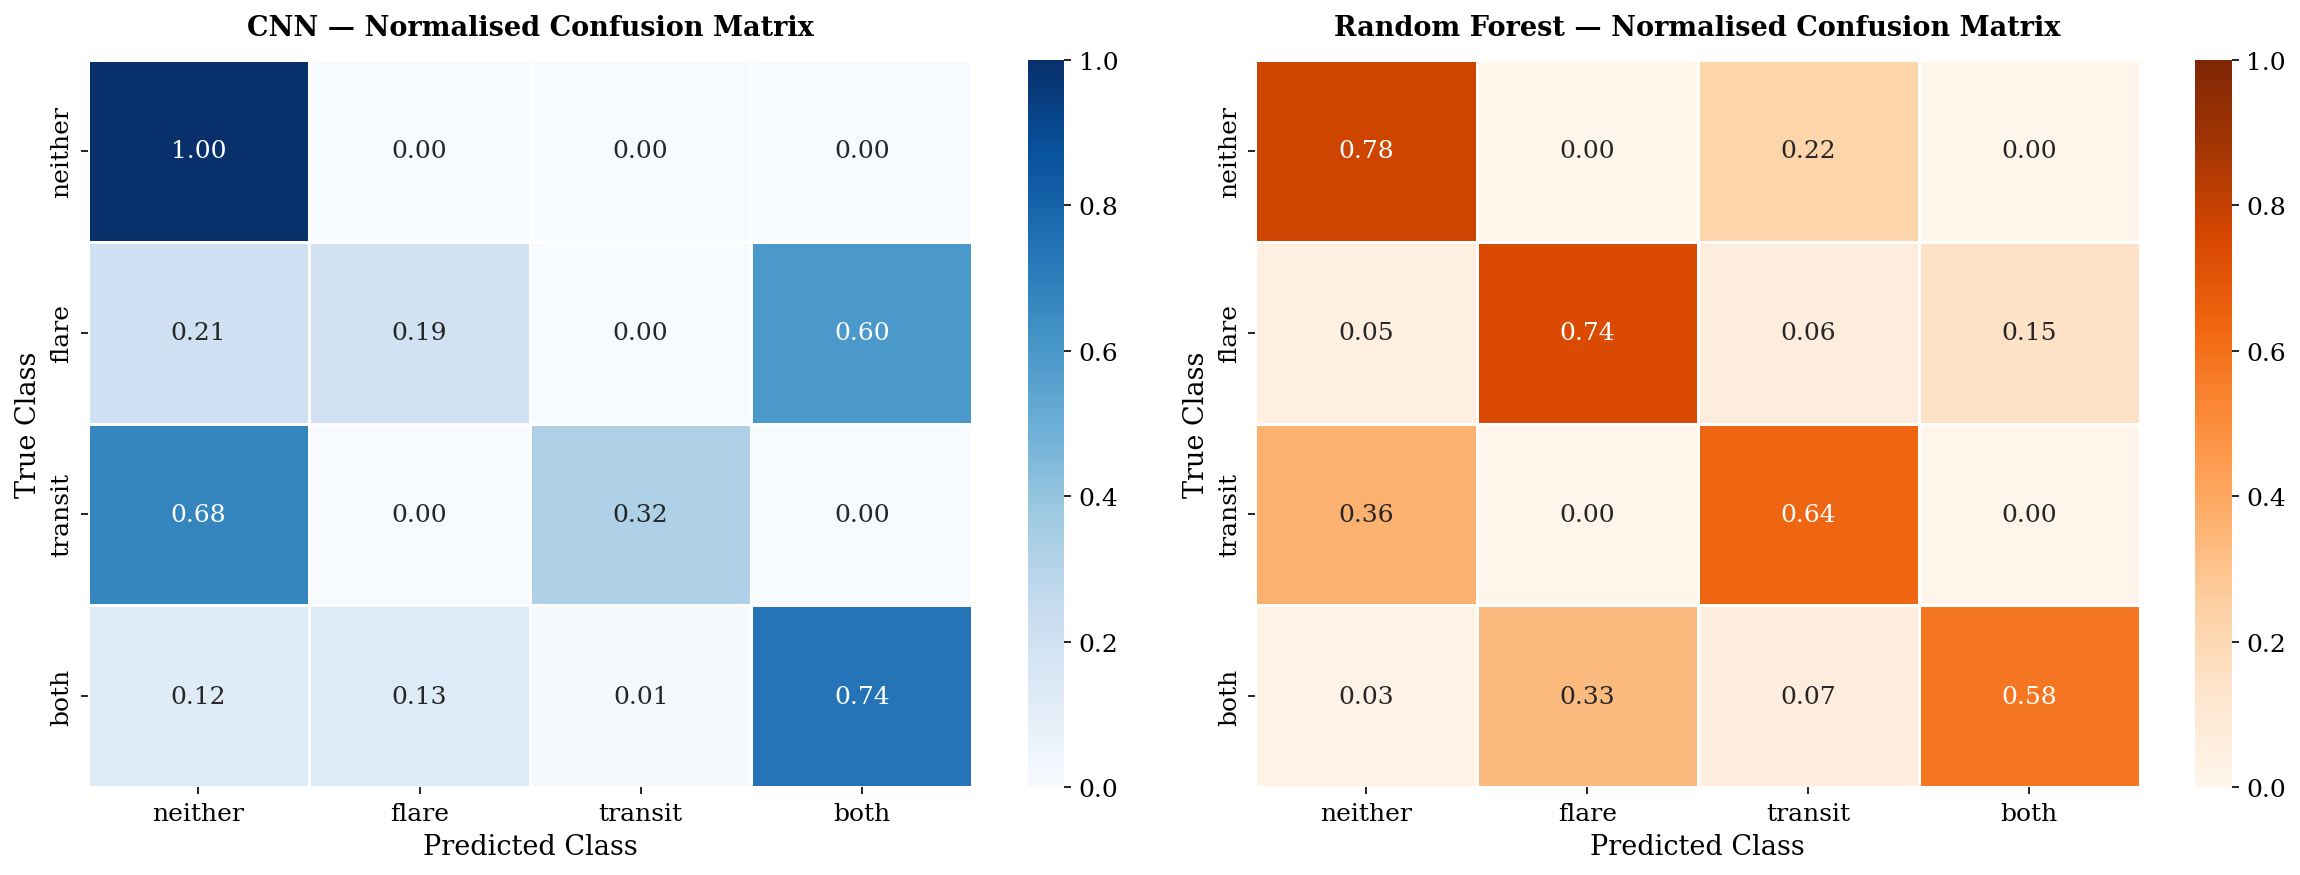

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_true, y_pred, title, cmap in [
    (axes[0], y_true_cnn, y_pred_cnn, "CNN",           "Blues"),
    (axes[1], y_true_rf,  y_pred_rf,  "Random Forest", "Oranges"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap=cmap,
        xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
        ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
        annot_kws={"size": 12}
    )
    ax.set_title(f"{title} — Normalised Confusion Matrix", fontweight='bold', pad=12)
    ax.set_ylabel("True Class")
    ax.set_xlabel("Predicted Class")

plt.tight_layout()
plt.savefig("img/comparison_confusion_matrices.pdf", bbox_inches='tight')
plt.show()


---
## 5. Detection Efficiency vs. Physical Parameters

The most astrophysically meaningful diagnostic: *how does detection probability
change as a function of the injected signal properties?*

A good classifier should:
- Approach P(detection) ≈ 1 for strong signals (large planets, bright flares)
- Have a well-defined sensitivity threshold below which detection fails
- Ideally, this threshold should be as low as possible

Both models are overlaid on the same axes so the sensitivity limits can be
read off directly.


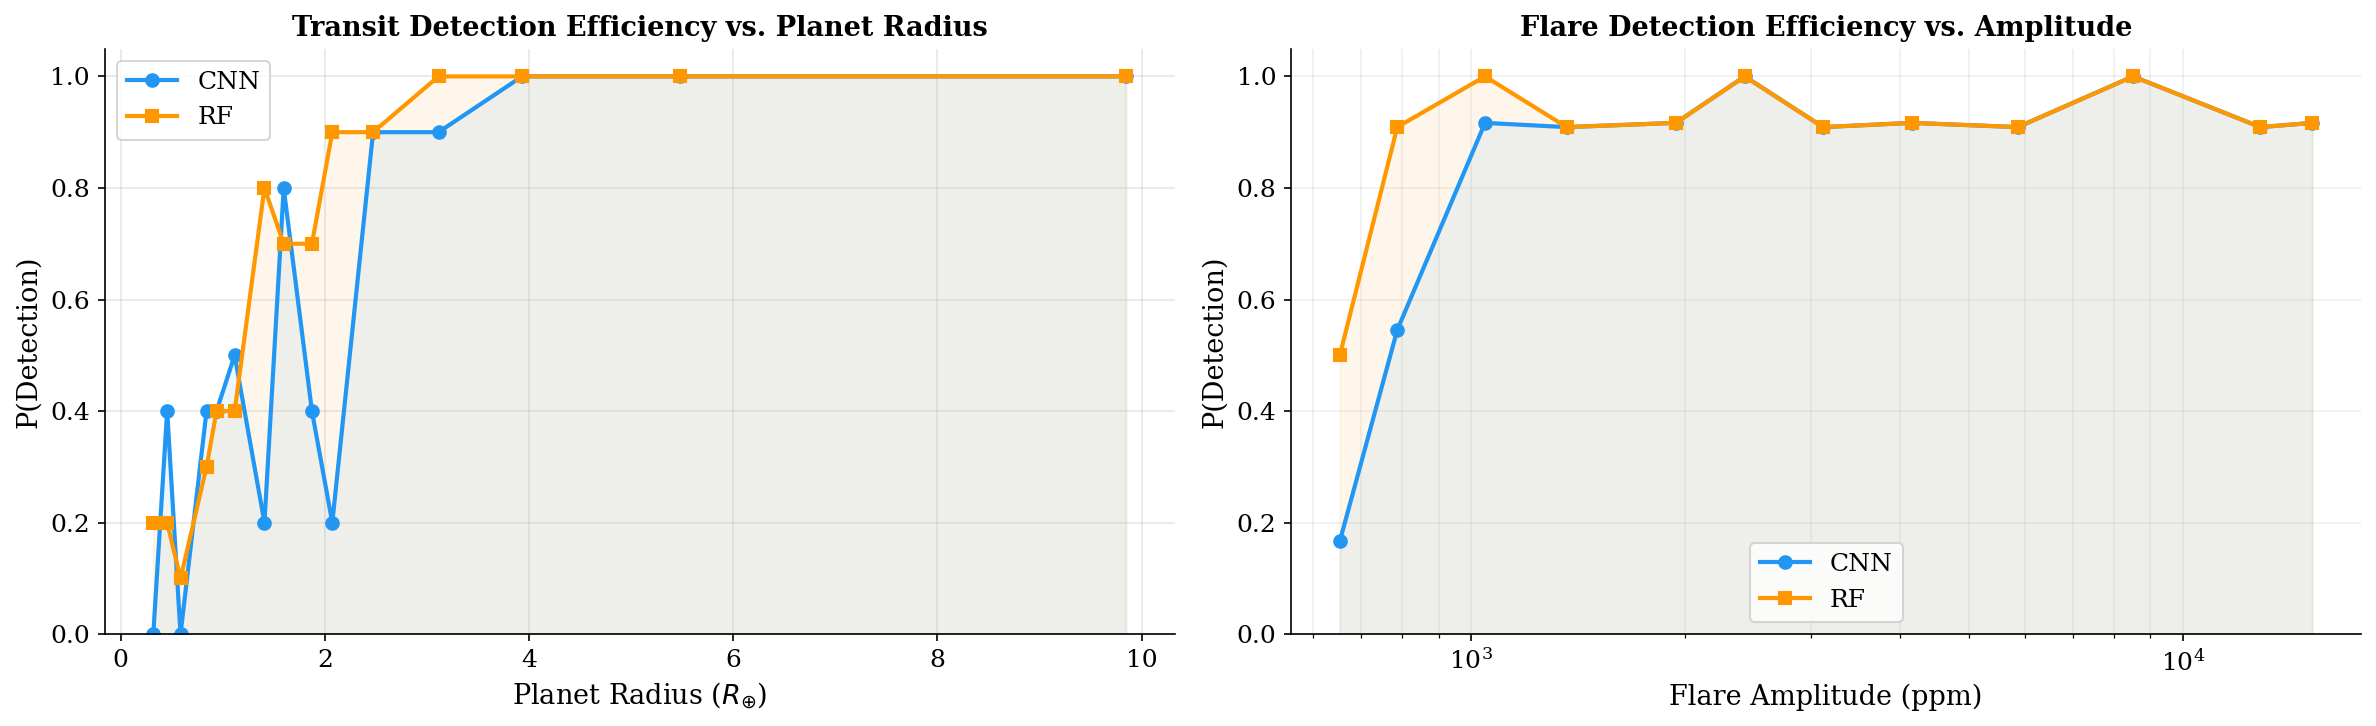

In [9]:
def detection_curve(df, feature_col, event_type='transit', bins=15):
    """
    Compute binned detection probability as a function of a physical parameter.
    Returns (midpoints, probabilities, counts).
    'Detection' means the model correctly identified the event *component*,
    regardless of the other class label.  e.g. a 'both' system counts as a
    transit detection if the model predicts 'transit' or 'both'.
    """
    valid = [event_type, 'both']
    subset = df[df['true_event_class'].isin(valid)].dropna(subset=[feature_col]).copy()
    subset['detected'] = subset['pred_event_class'].isin(valid).astype(int)

    try:
        subset['bin'] = pd.qcut(subset[feature_col], q=bins, duplicates='drop')
    except ValueError:
        subset['bin'] = pd.cut(subset[feature_col], bins=bins)

    stats = subset.groupby('bin', observed=True).agg(
        prob=('detected', 'mean'),
        mid=(feature_col, 'median'),
        count=('detected', 'count')
    ).dropna()

    return stats['mid'].values, stats['prob'].values, stats['count'].values


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Transit vs. planet radius ─────────────────────────────────────────────
ax = axes[0]
for df, color, label, marker in [
    (cnn, CNN_COLOR, 'CNN', 'o'),
    (rf,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'transit_radius_earth', 'transit', bins=15)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel(r"Planet Radius ($R_{\oplus}$)")
ax.set_ylabel("P(Detection)")
ax.set_title("Transit Detection Efficiency vs. Planet Radius", fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# ── Flare vs. amplitude ───────────────────────────────────────────────────
ax = axes[1]
for df, color, label, marker in [
    (cnn, CNN_COLOR, 'CNN', 'o'),
    (rf,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'flare_amplitude', 'flare', bins=12)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel("Flare Amplitude (ppm)")
ax.set_ylabel("P(Detection)")
ax.set_title("Flare Detection Efficiency vs. Amplitude", fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("img/comparison_detection_efficiency.pdf", bbox_inches='tight')
plt.show()


---
## 6. Robustness to Instrumental Drift

PLATO introduces systematic drift at five severity levels. The preprocessing
pipeline corrects for jumps and slow thermoelastic ramps, but residuals remain
at higher drift levels. This section tests how gracefully each model degrades
as the systematics worsen.

- **none**: clean synthetic photometry, no drift injected
- **low / medium / high / max**: increasing levels of thermoelastic drift from PSLS

The key question: is one model more or less sensitive to systematics than the other?


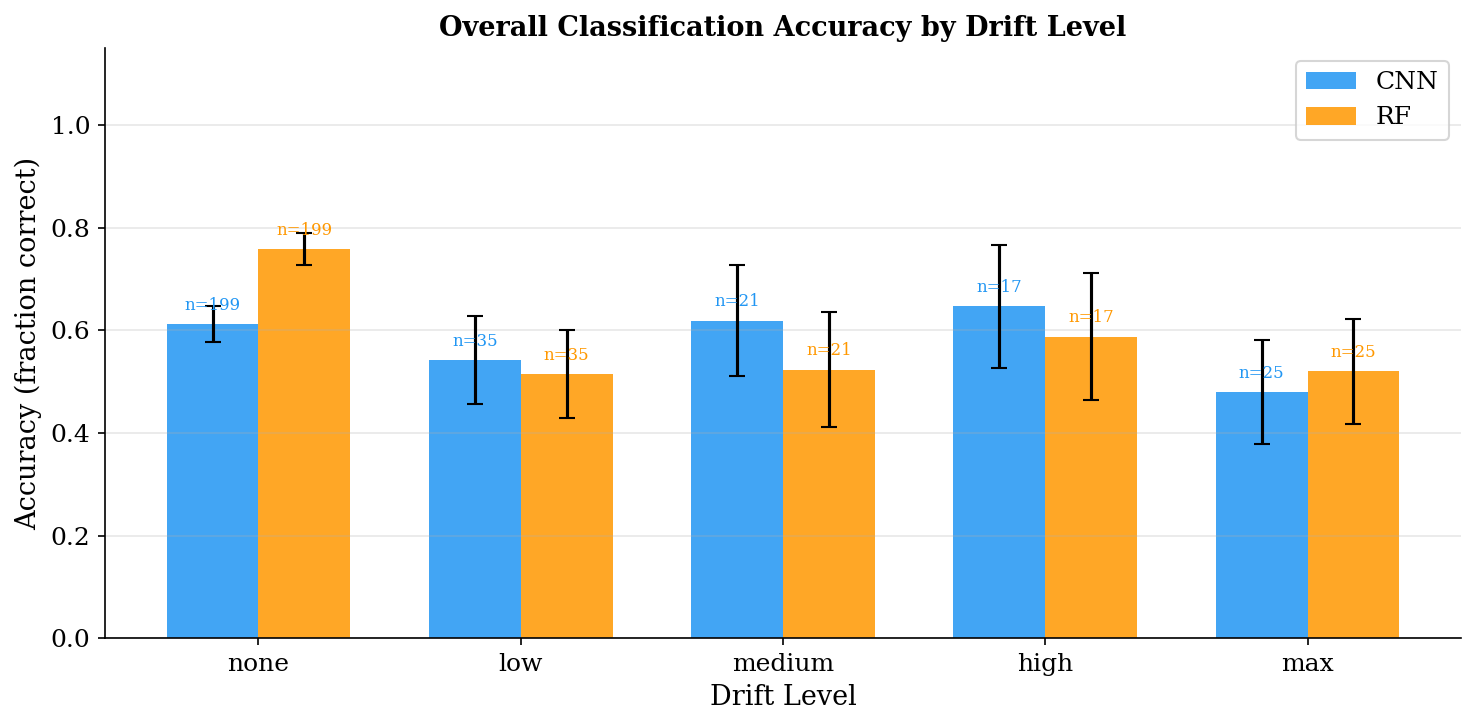

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.35
x = np.arange(len(DRIFT_ORDER))

for i, (df, color, label) in enumerate([
    (cnn, CNN_COLOR, 'CNN'),
    (rf,  RF_COLOR,  'RF'),
]):
    df = df.copy()
    df['correct'] = (df['pred_event_class'] == df['true_event_class']).astype(int)
    stats = (df.groupby('drift', observed=True)['correct']
               .agg(['mean', 'sem', 'count'])
               .reindex(DRIFT_ORDER))

    offset = (i - 0.5) * bar_width
    bars = ax.bar(x + offset, stats['mean'], width=bar_width,
                  color=color, label=label, alpha=0.85)
    ax.errorbar(x + offset, stats['mean'], yerr=stats['sem'],
                fmt='none', color='black', capsize=4, linewidth=1.5)

    # Annotate with n
    for j, (mean, n) in enumerate(zip(stats['mean'], stats['count'])):
        ax.text(x[j] + offset, mean + 0.02, f"n={int(n)}",
                ha='center', va='bottom', fontsize=8, color=color)

ax.set_xticks(x)
ax.set_xticklabels(DRIFT_ORDER)
ax.set_xlabel("Drift Level")
ax.set_ylabel("Accuracy (fraction correct)")
ax.set_title("Overall Classification Accuracy by Drift Level", fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("img/comparison_drift_accuracy.pdf", bbox_inches='tight')
plt.show()


---
## 7. Intrinsic Sensitivity — No Drift

Restricting to `drift = 'none'` isolates each model's **intrinsic sensitivity**
from the confounding effect of instrumental systematics. These curves represent
the best achievable performance on clean data, and set a ceiling for what improved
drift correction could recover.

Comparing §5 (all drift levels) vs. §7 (no drift) also quantifies how much
performance the drift is actually costing each model.


No-drift systems: CNN val = 199, RF val = 199


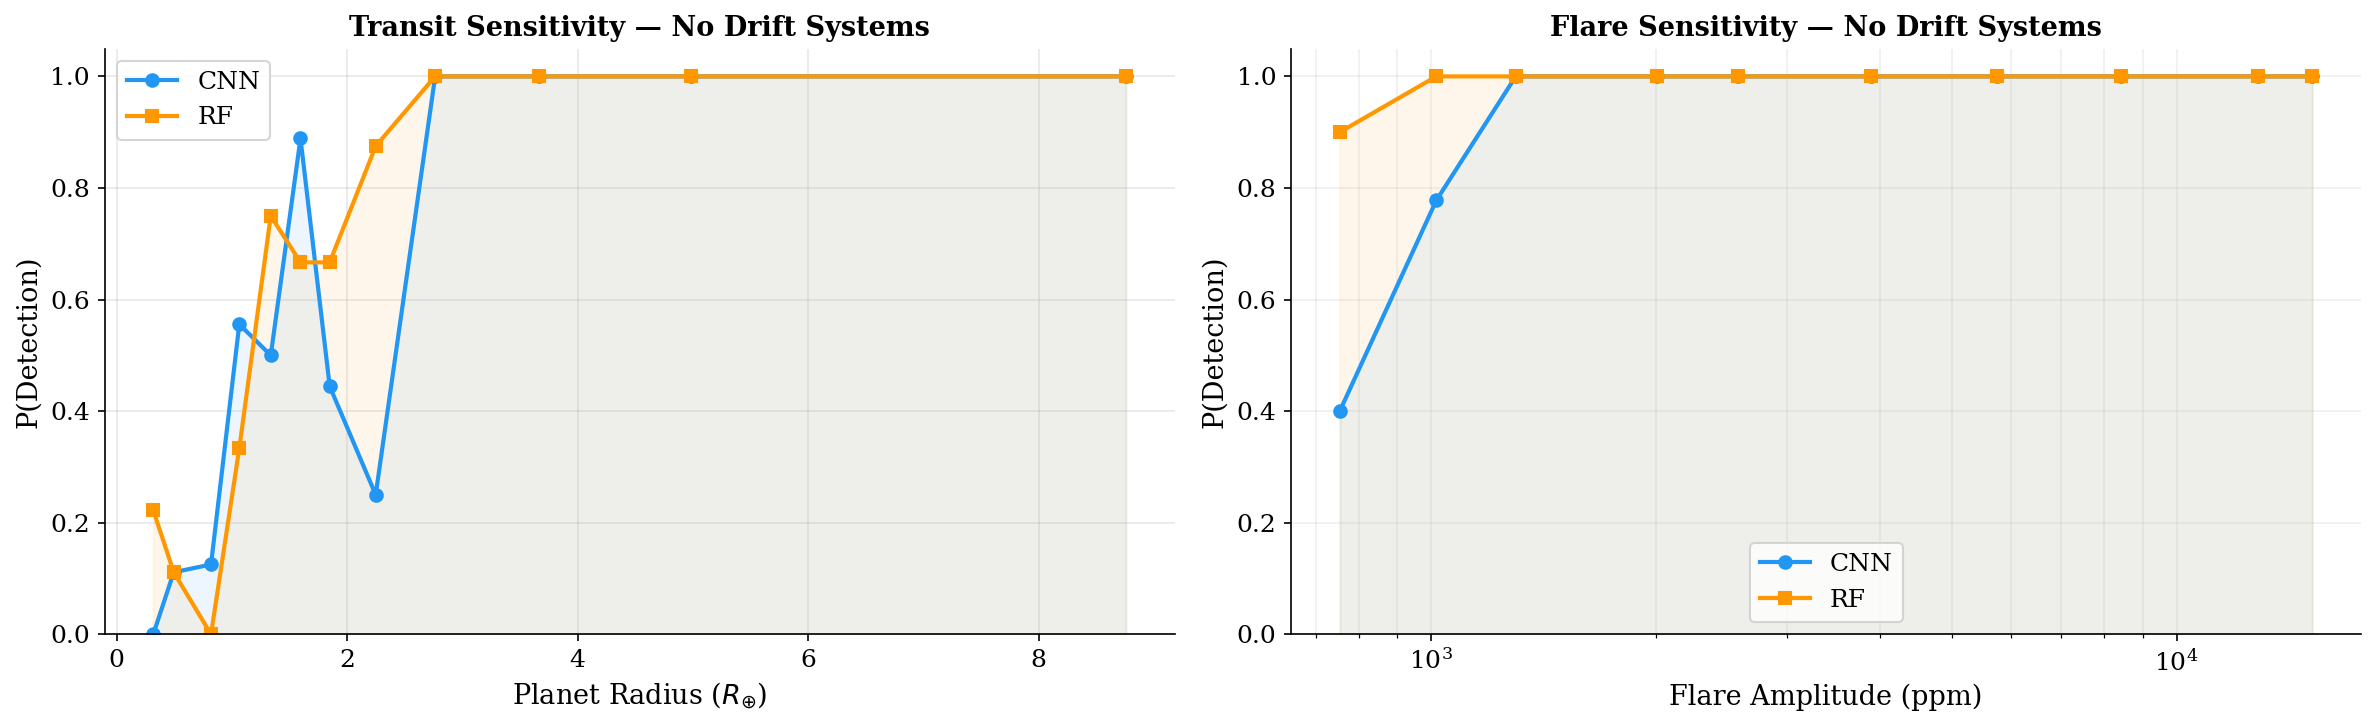

In [11]:
cnn_clean = cnn[cnn['drift'] == 'none'].copy()
rf_clean  = rf[rf['drift'] == 'none'].copy()

print(f"No-drift systems: CNN val = {len(cnn_clean)}, RF val = {len(rf_clean)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Transit ───────────────────────────────────────────────────────────────
ax = axes[0]
for df, color, label, marker in [
    (cnn_clean, CNN_COLOR, 'CNN', 'o'),
    (rf_clean,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'transit_radius_earth', 'transit', bins=12)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel(r"Planet Radius ($R_{\oplus}$)")
ax.set_ylabel("P(Detection)")
ax.set_title("Transit Sensitivity — No Drift Systems", fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

# ── Flare ─────────────────────────────────────────────────────────────────
ax = axes[1]
for df, color, label, marker in [
    (cnn_clean, CNN_COLOR, 'CNN', 'o'),
    (rf_clean,  RF_COLOR,  'RF',  's'),
]:
    mid, prob, cnt = detection_curve(df, 'flare_amplitude', 'flare', bins=10)
    ax.plot(mid, prob, color=color, marker=marker, linewidth=2,
            markersize=6, label=label)
    ax.fill_between(mid, 0, prob, alpha=0.08, color=color)

ax.set_xlabel("Flare Amplitude (ppm)")
ax.set_ylabel("P(Detection)")
ax.set_title("Flare Sensitivity — No Drift Systems", fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig("img/comparison_nodrift_sensitivity.pdf", bbox_inches='tight')
plt.show()


---
## 8. The "Both" Class — Simultaneous Flare + Transit

The `both` class is the hardest: the classifier must simultaneously detect two
morphologically distinct signals superimposed in a single light curve. The two
architectures approach this differently:

- **CNN**: two independent binary heads, so a "both" prediction arises naturally
  whenever *both* `head_flare > 0.5` and `head_transit > 0.28`. The heads are
  free to fire independently.
- **RF**: the `both` class is a single leaf in the tree ensemble. The model must
  recognise the combined statistical signature of a flare and a transit, which
  reduces the effective sample size for this class.

For each model, we show what fraction of true `both` systems are assigned to each
predicted class. Ideally the bar for `both` would be 1.0.


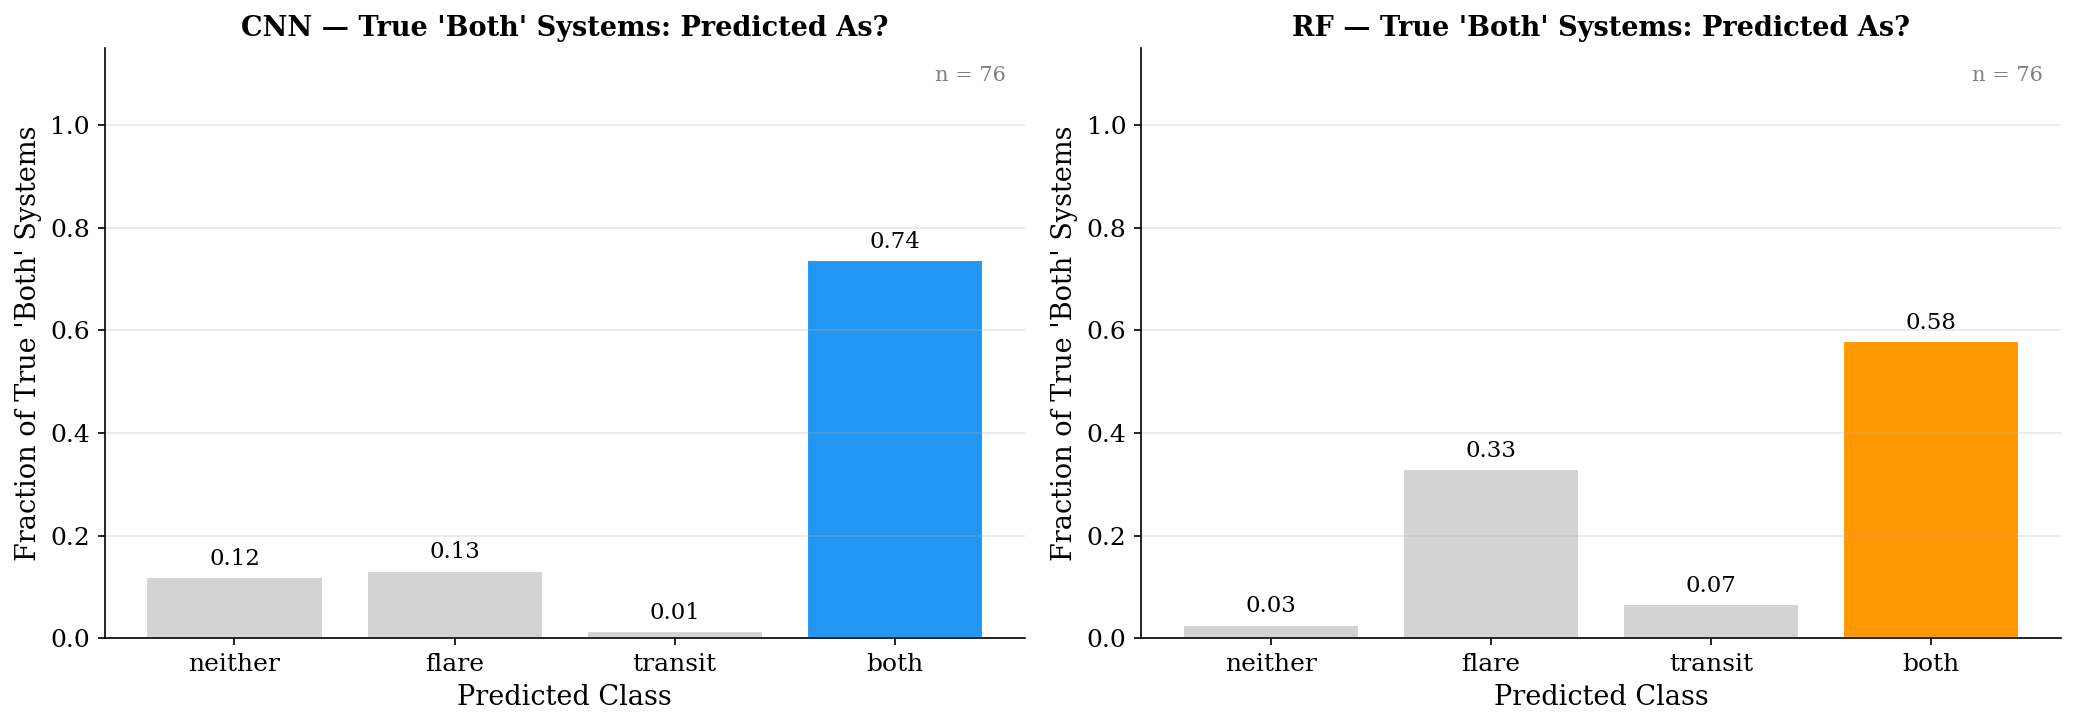

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in [
    (axes[0], cnn, 'CNN', CNN_COLOR),
    (axes[1], rf,  'RF',  RF_COLOR),
]:
    both_true = df[df['true_event_class'] == 'both']
    counts    = both_true['pred_event_class'].value_counts().reindex(CLASS_ORDER, fill_value=0)
    fractions = counts / len(both_true)

    bar_colors = [color if cls == 'both' else 'lightgrey' for cls in CLASS_ORDER]
    bars = ax.bar(CLASS_ORDER, fractions.values, color=bar_colors, edgecolor='white')

    for bar, val in zip(bars, fractions.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{val:.2f}", ha='center', va='bottom', fontsize=11)

    ax.set_title(f"{label} — True 'Both' Systems: Predicted As?", fontweight='bold')
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Fraction of True 'Both' Systems")
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.98, 0.97, f"n = {len(both_true)}", transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig("img/comparison_both_class.pdf", bbox_inches='tight')
plt.show()


---
## 9. Output Score Distributions

Score distributions reveal how *confident* each model is and how well-separated
the positive and negative classes are in probability space.

- A well-calibrated model pushes scores toward 0 and 1, with minimal mass near 0.5.
- Significant overlap between the positive and negative distributions near the
  threshold indicates the model is uncertain for those cases — often the
  physically challenging ones (small planets, faint flares).

### 9.1 CNN — per-head sigmoid probabilities


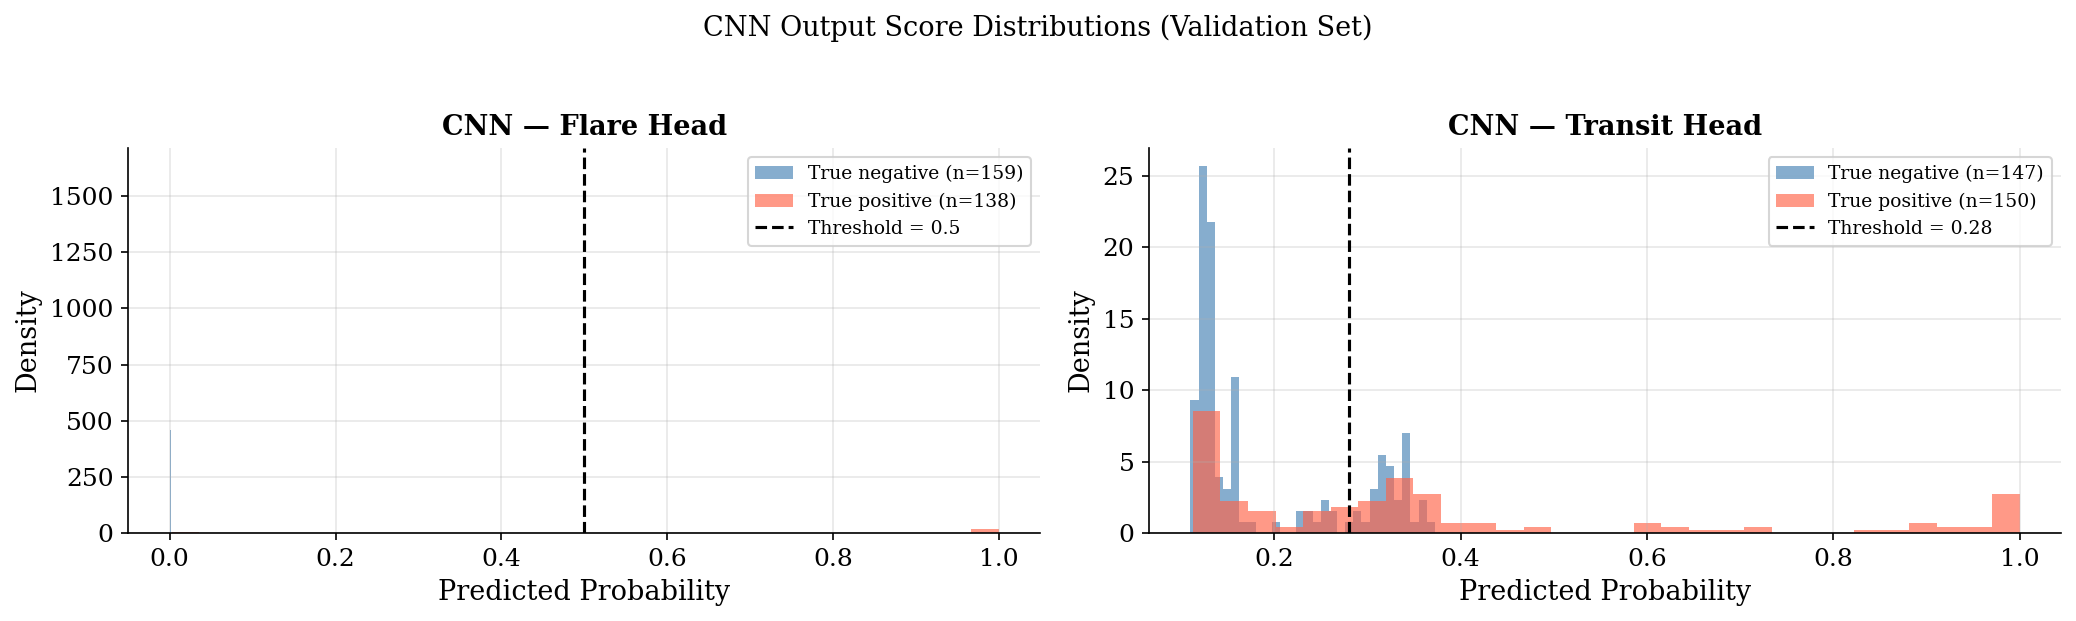

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, prob_col, true_col, title, thresh in [
    (axes[0], 'flare_prob',   'label_has_flares',  'Flare Head',   0.50),
    (axes[1], 'transit_prob', 'label_has_transit', 'Transit Head', 0.28),
]:
    pos = cnn[cnn[true_col] == 1][prob_col].dropna()
    neg = cnn[cnn[true_col] == 0][prob_col].dropna()

    ax.hist(neg, bins=30, alpha=0.65, color='steelblue',
            label=f'True negative (n={len(neg)})', density=True)
    ax.hist(pos, bins=30, alpha=0.65, color='tomato',
            label=f'True positive (n={len(pos)})', density=True)
    ax.axvline(thresh, color='black', linestyle='--',
               linewidth=1.5, label=f'Threshold = {thresh}')

    ax.set_title(f"CNN — {title}", fontweight='bold')
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("CNN Output Score Distributions (Validation Set)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("img/cnn_score_distributions.pdf", bbox_inches='tight')
plt.show()


### 9.2 Random Forest — per-class softmax probabilities


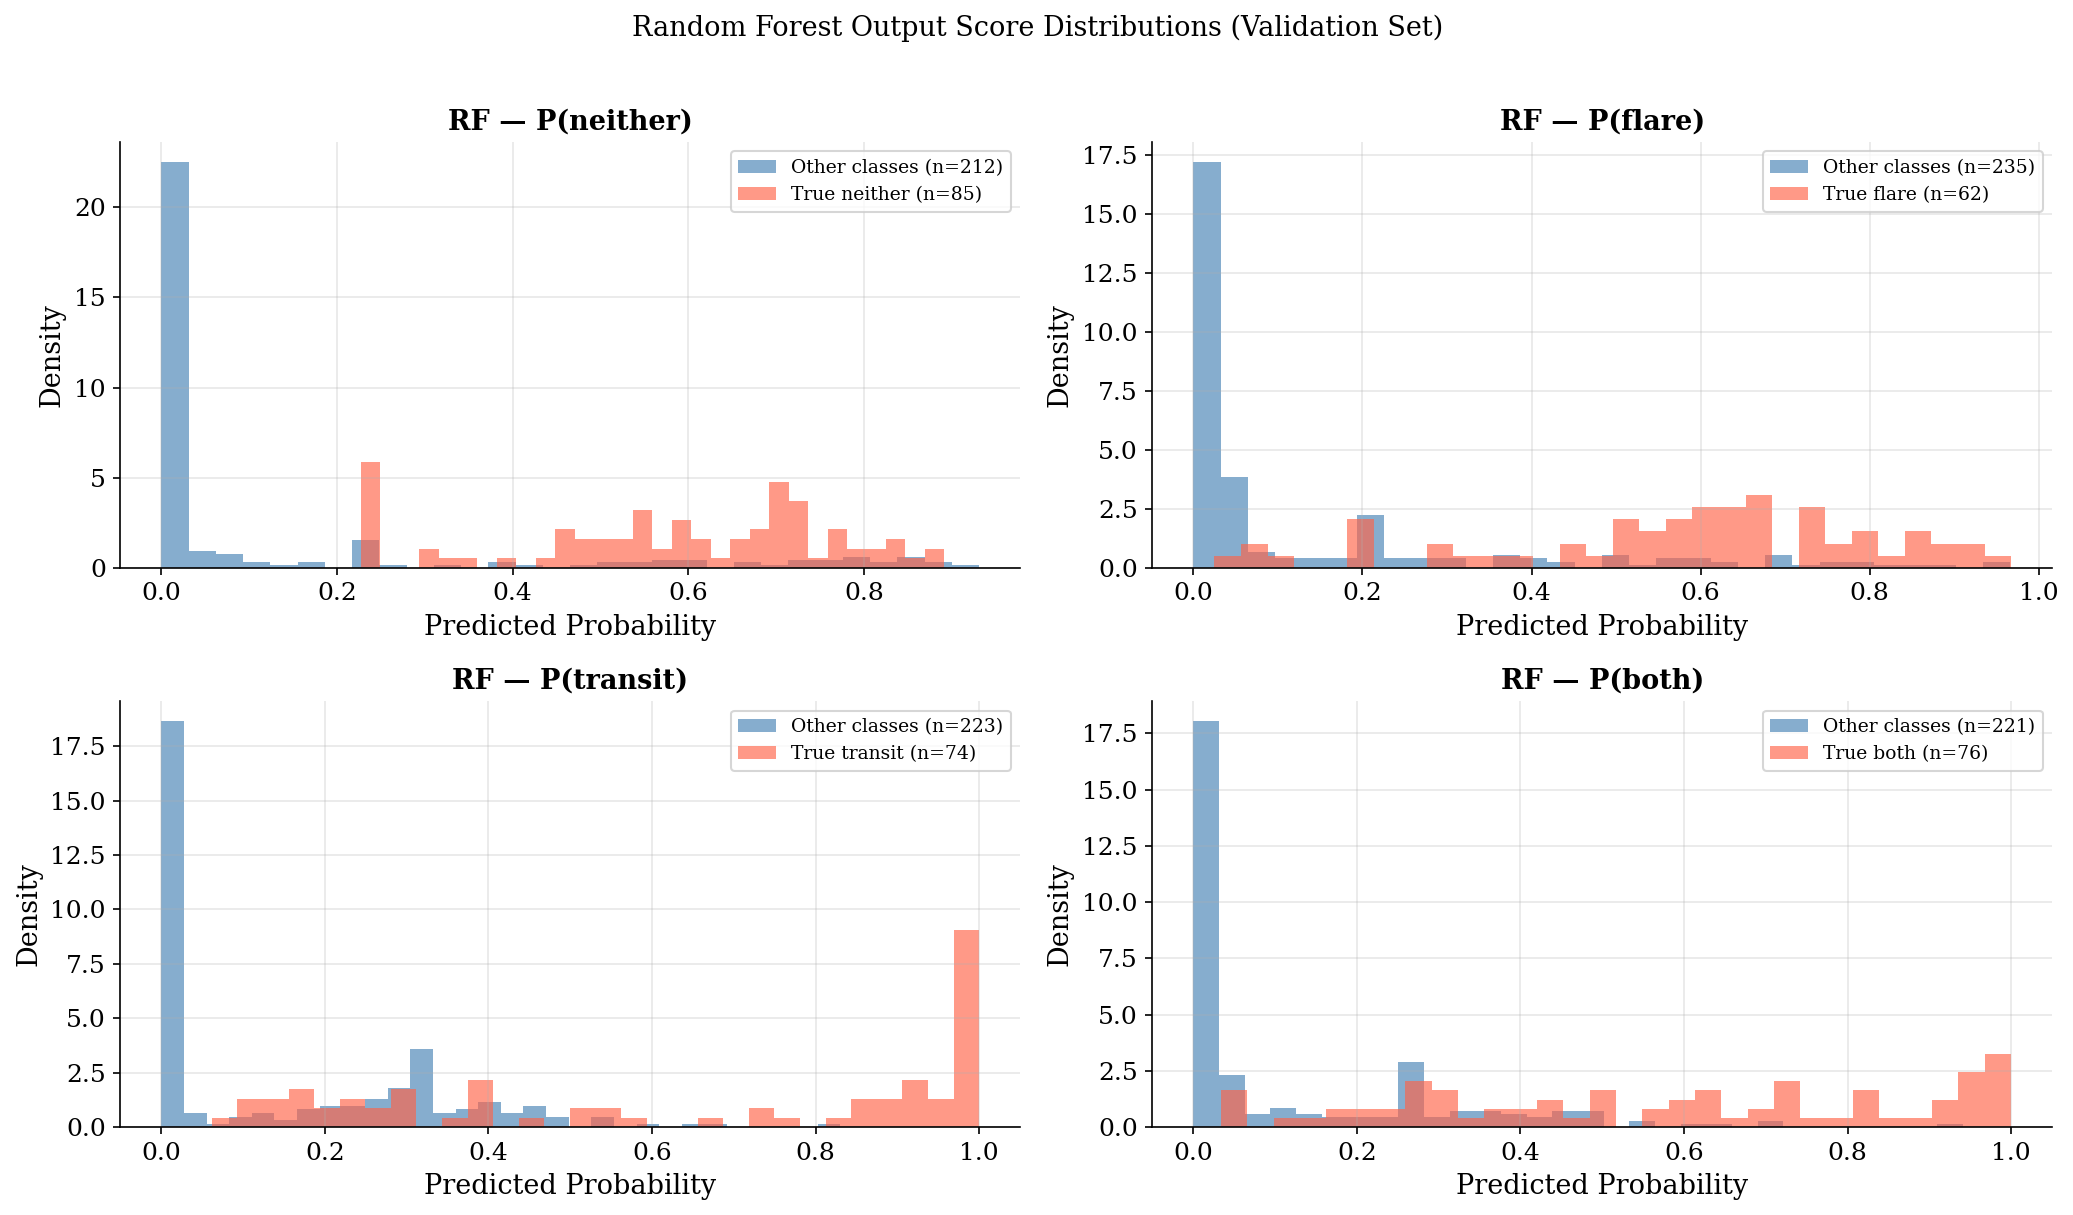

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, cls in zip(axes, CLASS_ORDER):
    prob_col = f"p_{cls}"
    is_true  = rf['true_event_class'] == cls

    ax.hist(rf.loc[~is_true, prob_col], bins=30, alpha=0.65, color='steelblue',
            label=f'Other classes (n={(~is_true).sum()})', density=True)
    ax.hist(rf.loc[is_true,  prob_col], bins=30, alpha=0.65, color='tomato',
            label=f'True {cls} (n={is_true.sum()})', density=True)

    ax.set_title(f"RF — P({cls})", fontweight='bold')
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Random Forest Output Score Distributions (Validation Set)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("img/rf_score_distributions.pdf", bbox_inches='tight')
plt.show()


---
## 10. Random Forest Feature Importance

Gini importance (mean decrease in impurity) shows which hand-crafted features
drive the RF's decisions. This has two uses:

1. **Validates the feature engineering**: if BLS power dominates for transit
   classification, the explicit periodicity search is genuinely useful.
2. **Illuminates what the CNN might be learning**: if the RF's most important
   transit features are BLS-derived, the CNN must learn an equivalent detector
   implicitly through its convolutional filters.

Features that are important for *all* classes will be near the top; class-specific
diagnostics may be less obvious here since importance is averaged over all splits.


In [15]:
rf_model = rf_clf.named_steps['model']

print(f"Random Forest: {rf_model.n_estimators} trees")
print(f"Feature count: {rf_model.n_features_in_}")
print(f"Classes:       {list(rf_model.classes_)}")

# ── Load feature names from the generated txt file ─────────────────────────
try:
    with open("../data/models/feature_columns.txt", "r") as f:
        names = [line.strip() for line in f if line.strip()]
except FileNotFoundError:
    print("Warning: feature_columns.txt not found. Falling back to default indices.")
    feat_names = [f"feature_{i}" for i in range(rf_model.n_features_in_)]

print(f"Feature names:")
for i, name in enumerate(names, 1):
    print(f"  {i:2d}. {name}")


feat_imp = (pd.DataFrame({'feature': feat_names, 'importance': importances})
              .sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(10, max(5, len(feat_names) * 0.4)))
sns.barplot(data=feat_imp, x='importance', y='feature',
            hue='feature', palette='viridis', legend=False, ax=ax)
ax.set_title("Random Forest — Feature Importance (Gini)", fontweight='bold')

ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("img/rf_feature_importance.pdf", bbox_inches='tight')
plt.show()

print("\nRanked features:")
print(feat_imp.to_string(index=False))


Random Forest: 300 trees
Feature count: 11
Classes:       ['both', 'flare', 'neither', 'transit']
Feature names:
   1. skew
   2. kurtosis
   3. negative_outlier_fraction
   4. flare_p99_snr
   5. flare_positive_area_ppm_day
   6. flare_positive_fraction_3sigma
   7. flare_longest_run_3sigma
   8. flare_longest_duration_3sigma_days
   9. bls_power
  10. bls_depth_ppm
  11. bls_depth_snr


NameError: name 'feat_names' is not defined

---
## 11. Head-to-Head Summary

A single consolidated table capturing every key metric. Delta = CNN − RF, so
positive values favour the CNN.


In [ ]:
def component_recall(df, event_type):
    """Fraction of true event_type systems where the model detected the component."""
    true_pos = df[df['true_event_class'].isin([event_type, 'both'])]
    detected = true_pos['pred_event_class'].isin([event_type, 'both'])
    return detected.mean()

rows = []

# Overall accuracy
cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
rf_acc  = accuracy_score(y_true_rf,  y_pred_rf)
rows.append({'Metric': 'Overall accuracy',
             'CNN': f"{cnn_acc:.3f}", 'RF': f"{rf_acc:.3f}",
             'Delta': f"{cnn_acc - rf_acc:+.3f}"})

# Macro F1
cnn_mf1 = f1_score(y_true_cnn, y_pred_cnn, average='macro', labels=CLASS_ORDER)
rf_mf1  = f1_score(y_true_rf,  y_pred_rf,  average='macro', labels=CLASS_ORDER)
rows.append({'Metric': 'Macro F1',
             'CNN': f"{cnn_mf1:.3f}", 'RF': f"{rf_mf1:.3f}",
             'Delta': f"{cnn_mf1 - rf_mf1:+.3f}"})

# Per-class F1
for cls in CLASS_ORDER:
    c = f1_score(y_true_cnn, y_pred_cnn, labels=[cls], average='macro')
    r = f1_score(y_true_rf,  y_pred_rf,  labels=[cls], average='macro')
    rows.append({'Metric': f"F1 — {cls}",
                 'CNN': f"{c:.3f}", 'RF': f"{r:.3f}",
                 'Delta': f"{c - r:+.3f}"})

# Transit and flare component recall
for event in ['transit', 'flare']:
    c = component_recall(cnn, event)
    r = component_recall(rf,  event)
    rows.append({'Metric': f"{event.capitalize()} component recall",
                 'CNN': f"{c:.3f}", 'RF': f"{r:.3f}",
                 'Delta': f"{c - r:+.3f}"})

# Accuracy drop from no-drift to max-drift
for df, label in [(cnn, 'CNN'), (rf, 'RF')]:
    df2 = df.copy()
    df2['correct'] = (df2['pred_event_class'] == df2['true_event_class']).astype(int)
    by_drift = df2.groupby('drift')['correct'].mean()
    drop = by_drift.get('none', np.nan) - by_drift.get('max', np.nan)
    if label == 'CNN':
        cnn_drop = drop
    else:
        rf_drop = drop

rows.append({'Metric': 'Accuracy drop: none -> max drift',
             'CNN': f"{cnn_drop:.3f}", 'RF': f"{rf_drop:.3f}",
             'Delta': f"{cnn_drop - rf_drop:+.3f}"})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print("\nDelta = CNN - RF  (positive = CNN wins, negative = RF wins)")


                          Metric   CNN    RF  Delta
                Overall accuracy 0.596 0.684 -0.088
                        Macro F1 0.534 0.682 -0.148
                    F1 — neither 0.702 0.721 -0.019
                      F1 — flare 0.286 0.692 -0.406
                    F1 — transit 0.485 0.631 -0.146
                       F1 — both 0.663 0.682 -0.019
        Transit component recall 0.540 0.640 -0.100
          Flare component recall 0.833 0.899 -0.065
Accuracy drop: none -> max drift 0.133 0.239 -0.106

Delta = CNN - RF  (positive = CNN wins, negative = RF wins)


---
## 12. Discussion & Conclusions

*(Fill in after running the notebook and reviewing the outputs.)*

This section should address the following questions based on your results:

---

### 12.1 Overall accuracy

> Which model achieves higher accuracy? Is the difference statistically
> meaningful given the validation set size, or within noise?

---

### 12.2 Transit detection (the hardest task)

> At what planet radius does each model's detection probability fall below 50%?
> This is the **sensitivity threshold** — the key astrobiological figure of merit.
> A lower threshold means the pipeline can characterise smaller, potentially
> habitable planets.
>
> Does the CNN's raw-waveform approach out-compete the RF's BLS-augmented features
> for transit detection? If the BLS features are powerful, the RF may win; if the
> morphological cues are subtle, the CNN's learned filters may generalise better.

---

### 12.3 Flare detection

> Flare detection is generally easier (large, sharp, positive excursions).
> Do both models saturate near 100% above some amplitude threshold?
> Does the CNN's ability to detect rapid rise / exponential decay help,
> or are the RF's σ-clipping statistics sufficient?

---

### 12.4 Robustness to drift

> Does one model degrade more gracefully than the other as drift increases?
> The CNN sees the raw flux and might be more sensitive to residual baseline
> trends. The RF's features include skewness and kurtosis, which could be
> affected by drift residuals but are also somewhat drift-invariant.

---

### 12.5 The "both" class

> The CNN's multi-label formulation (two independent heads) has a structural
> advantage for the `both` class — it doesn't need explicit training examples
> of the combined signal to learn each component separately.
> Does this show up in the results?

---

### 12.6 Recommendations

Based on the comparison:
- Which model would you deploy as the primary classifier?
- What are the strongest arguments for keeping the other as a cross-check?
- What would a Transformer classifier (with attention over the time series)
  likely improve upon, and where would it face the same limitations?
